In [1]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from PIL import Image
from PIL.ExifTags import TAGS
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support, roc_curve, auc
import joblib

In [2]:
# Increase the pixel limit for large images
Image.MAX_IMAGE_PIXELS = None

In [3]:
# Function to extract metadata from an image
def extract_metadata(image_path):
    image = Image.open(image_path)
    metadata = {"Image Path": image_path}
    info = image._getexif()
    if info:
        for tag, value in info.items():
            tag_name = TAGS.get(tag, tag)
            metadata[tag_name] = value
    return metadata
    
# Function to extract numerical part from a filename for sorting
def extract_number(filename):
    match = re.search(r'(\d+)', filename)
    return int(match.group(1)) if match else float('inf')

# Function to load and preprocess images from folders
def load_and_preprocess_images_with_folders(image_folder):
    images = []
    labels = []
    metadata_list = []
    for label_folder in os.listdir(image_folder):
        label_path = os.path.join(image_folder, label_folder)
        if os.path.isdir(label_path):
            for filename in sorted(os.listdir(label_path), key=extract_number):
                if filename.endswith(('.jpg', '.jpeg', '.png')):
                    image_path = os.path.join(label_path, filename)

                    # Extract metadata
                    metadata = extract_metadata(image_path)
                    metadata_list.append(metadata)

                    # Preprocess image
                    image = cv2.imread(image_path)
                    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                    _, segmented_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
                    resized_image = cv2.resize(segmented_image, (256, 256))
                    normalized_image = resized_image / 255.0  # Normalize to [0, 1]
                    images.append(normalized_image.flatten())
                    labels.append(label_folder)

                    # Uncomment the line below to visualize original, segmented, and resized images
                    visualize_before_after(image, segmented_image, resized_image, f'Label: {label_folder}')
    return np.array(images), np.array(labels), metadata_list

# Function to visualize original, segmented, and resized images
def visualize_before_after(original, segmented, resized, title):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(f'{title} - Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(segmented, cmap='gray')
    plt.title(f'{title} - Segmented')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(resized, cmap='gray')
    plt.title(f'{title} - Resized (256x256)')
    plt.axis('off')

    plt.show()

# Function to save obj metadata to a CSV file
def save_obj_metadata(metadata_list, output_path):
    metadata_df = pd.DataFrame(metadata_list)
    metadata_df.to_csv(output_path, index=False)
    print("Obj Image Metadata:")
    print(metadata_df.sample(n=5))
    
# Function to extract metadata from all images in algo
def extract_metadata_from_folder(folder_path, output_csv_path):
    metadata_list = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(('.jpg', '.jpeg', '.png')):
                image_path = os.path.join(root, file)
                metadata = extract_metadata(image_path)
                metadata_list.append(metadata)
    
    # Save algo metadata to a CSV file
    metadata_df = pd.DataFrame(metadata_list)
    metadata_df.to_csv(output_csv_path, index=False)
    print("Algo Image Metadata:")
    print(metadata_df.sample(n=5))

# Function to save preprocessed images and labels to an HDF5 file
def save_to_hdf5(images, labels, output_path):
    with h5py.File(output_path, 'w') as h5file:
        h5file.create_dataset('images', data=images)
        h5file.create_dataset('labels', data=np.bytes_(labels))  # Convert labels to string dtype
        
# Function to load preprocessed images and labels from an HDF5 file
def load_from_hdf5(input_path):
    with h5py.File(input_path, 'r') as h5file:
        images = h5file['images'][:]
        labels = h5file['labels'][:].astype('U13')  # Convert bytes to string
    return images, labels

# Function to plot GridSearchCV results
def plot_grid_search(cv_results, param_grid):
    mean_test_scores = cv_results['mean_test_score']
    params = cv_results['params']

    n_neighbors = param_grid['n_neighbors']
    metrics = param_grid['metric']

    uniform_scores = []
    distance_scores = []

    for metric in metrics:
        for n in n_neighbors:
            for param in params:
                if param['metric'] == metric and param['n_neighbors'] == n:
                    if param['weights'] == 'uniform':
                        uniform_scores.append((n, metric, mean_test_scores[params.index(param)]))
                    elif param['weights'] == 'distance':
                        distance_scores.append((n, metric, mean_test_scores[params.index(param)]))

    fig, axs = plt.subplots(1, len(metrics), figsize=(18, 5))

    for i, metric in enumerate(metrics):
        unif_n = [x[0] for x in uniform_scores if x[1] == metric]
        unif_score = [x[2] for x in uniform_scores if x[1] == metric]
        dist_n = [x[0] for x in distance_scores if x[1] == metric]
        dist_score = [x[2] for x in distance_scores if x[1] == metric]

        # Plot uniform scores
        axs[i].plot(unif_n, unif_score, label=f'uniform', color='red', marker='o')
        # Plot distance scores
        axs[i].plot(dist_n, dist_score, label=f'distance', color='orange', marker='^')

        # Find and plot the highest uniform score
        max_unif_score = max(unif_score)
        max_unif_idx = unif_score.index(max_unif_score)
        axs[i].plot(unif_n[max_unif_idx], max_unif_score, 'o', markersize=10, color='red')
        axs[i].text(unif_n[max_unif_idx], max_unif_score, f'{max_unif_score:.4f}', color='red', fontsize=12, ha='right')

        # Find and plot the highest distance score
        max_dist_score = max(dist_score)
        max_dist_idx = dist_score.index(max_dist_score)
        axs[i].plot(dist_n[max_dist_idx], max_dist_score, '^', markersize=10, color='orange')
        axs[i].text(dist_n[max_dist_idx], max_dist_score, f'{max_dist_score:.4f}', color='orange', fontsize=12, ha='right')

        axs[i].set_xlabel('Number of Neighbors')
        axs[i].set_ylabel('Mean Test Score')
        axs[i].set_title(f'{metric}')
        axs[i].legend(loc='best')
        axs[i].grid(True)  # Add grid

    plt.tight_layout()
    plt.show()
    
# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Function to plot ROC curve
def plot_roc_curve(y_test, y_pred, classes):
    color_mapping = {
        'black': 'black',
        'gray': 'grey',
        'red': 'red',
        'yellow': 'yellow',
    }

    plt.figure()
    for label in classes:
        fpr, tpr, _ = roc_curve(y_test == label, y_pred == label)
        roc_auc = auc(fpr, tpr)
        color = color_mapping.get(label, 'blue')
        plt.plot(fpr, tpr, color=color, label=f'ROC curve of class {label} (area = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# Function to evaluate the model and display performance metrics
def evaluate_model(y_test, y_pred, classes):
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Accuracy Score: ", accuracy_score(y_test, y_pred))

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-score: {f1:.2f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    plot_confusion_matrix(cm, classes=classes, title='Confusion Matrix')
    plt.show()

    plot_roc_curve(y_test, y_pred, classes)

# Function to save models to disk
def save_models(knn_model, lda_model, knn_path='best_knn_model.pkl', lda_path='lda_model.pkl'):
    joblib.dump(knn_model, knn_path)
    joblib.dump(lda_model, lda_path)

In [4]:
# Specify the image folder and output paths
obj_image_folder = 'obj'
obj_metadata_csv_path = 'obj_metadata.csv'
algo_image_folder = 'algo'
algo_metadata_csv_path = 'algo_metadata.csv'
h5file_path = 'preprocessed_images.h5'

In [ ]:
# Load and preprocess images
images, labels, metadata_list = load_and_preprocess_images_with_folders(obj_image_folder)

In [6]:
# Save obj metadata to CSV
save_obj_metadata(metadata_list, obj_metadata_csv_path)

# Extract metadata from the 'algo' folder and save to CSV
extract_metadata_from_folder(algo_image_folder, algo_metadata_csv_path)

# Save preprocessed images and labels to an HDF5 file
save_to_hdf5(images, labels, h5file_path)

Obj Image Metadata:
             Image Path  ExifOffset  \
333     obj\red\94.jpeg       404.0   
27     obj\black\28.jpg       404.0   
411   obj\yellow\52.jpg       212.0   
272     obj\red\33.jpeg       102.0   
478  obj\yellow\119.jpg       362.0   

                                                 59932 ExifVersion  \
333                                                NaN     b'0220'   
27                                                 NaN     b'0220'   
411                                                NaN     b'0220'   
272                                                NaN     b'0221'   
478  b'\x1c\xea\x00\x00\x00\x01\x00\x00\x00\x00\x00...     b'0220'   

     ResolutionUnit  Orientation  YCbCrPositioning XResolution YResolution  \
333             2.0          0.0               2.0        72.0        72.0   
27              2.0          1.0               2.0        72.0        72.0   
411             2.0          8.0               1.0        72.0        72.0   
272         

In [7]:
# Feature Extraction using Linear Discriminant Analysis (LDA)
lda = LDA(n_components=min(len(images[0]), len(np.unique(labels)) - 1))
lda_features = lda.fit_transform(images, labels)

In [8]:
# Part Recognition using K-Nearest Neighbors (KNN)
X_train, X_test, y_train, y_test = train_test_split(lda_features, labels, test_size=0.4, random_state=42)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation accuracy: 0.9514216575922566


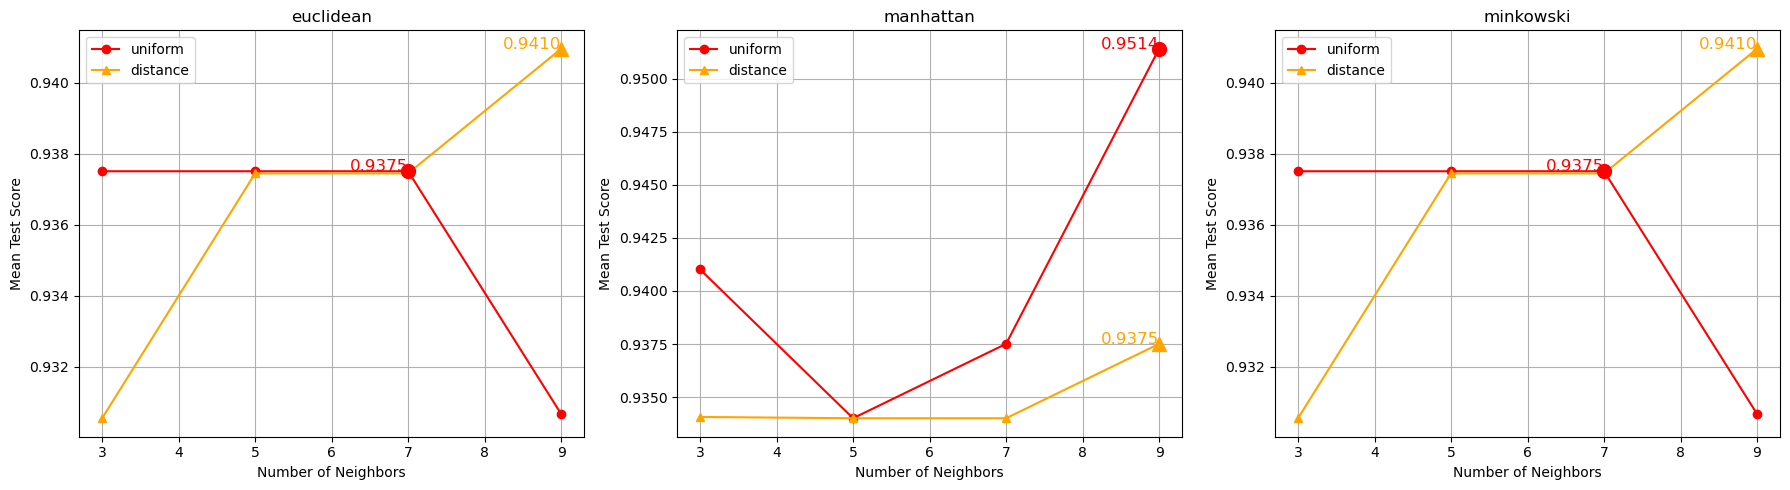

In [9]:
# Hyperparameter tuning for KNN using GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_}")

# Plot GridSearchCV results
plot_grid_search(grid_search.cv_results_, param_grid)

Classification Report:
               precision    recall  f1-score   support

       black       1.00      1.00      1.00        59
        gray       0.86      0.88      0.87        43
         red       0.87      0.87      0.87        38
      yellow       1.00      0.98      0.99        52

    accuracy                           0.94       192
   macro avg       0.93      0.93      0.93       192
weighted avg       0.94      0.94      0.94       192

Accuracy Score:  0.9427083333333334
Precision: 0.94
Recall: 0.94
F1-score: 0.94
Confusion Matrix:
 [[59  0  0  0]
 [ 0 38  5  0]
 [ 0  5 33  0]
 [ 0  1  0 51]]


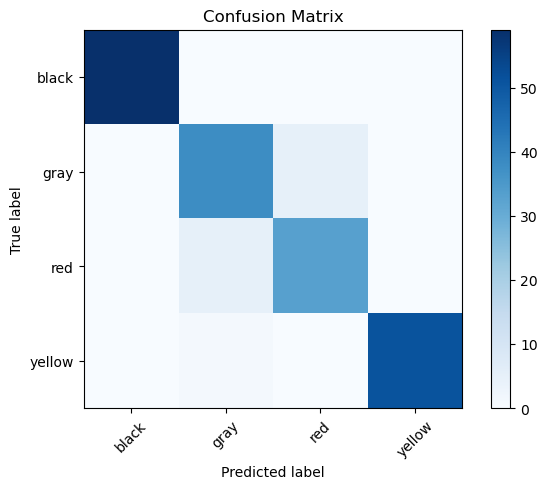

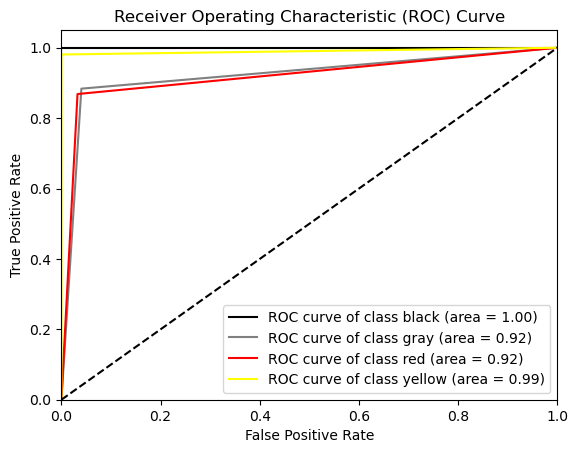

In [10]:
# Train the best model
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)

# Predictions
y_pred = best_knn.predict(X_test)

# Evaluate the model
evaluate_model(y_test, y_pred, classes=np.unique(labels))

In [11]:
# Save the trained KNN model and LDA object
save_models(best_knn, lda)